# 03 · Wine Quality — Feature Engineering & Transformations

## Part 3 — Feature Engineering & Transformations

Before modelling, prepare the features. The EDA flagged **right-skew** and **outliers** (which hurt
linear and distance-based models, though not trees) and **collinearity**. Here we:

1. **transform** the skewed features (log) and see which improve,
2. **inspect the outliers** (real extreme wines, not errors),
3. **engineer chemically-meaningful features** — and find a ratio that beats every raw feature,
4. ask honestly: **does any of this actually help?** (answer: it depends on the model).

A theme worth stating up front: *feature engineering is model-dependent* — transforms that rescue a
linear model do nothing for a gradient-boosted tree.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

df = data.dedup(data.clean())     # dedup FIRST — modelling-oriented from here on
print("modelling rows (deduped):", len(df))

setup ok | numpy 2.1.3 | pandas 2.3.3
modelling rows (deduped): 5320


### 1. Taming the skew

Several features have long right tails. A **log1p** transform (`log(1+x)`) pulls them in. It works
well for sugar and the acidities, over-corrects free SO₂, and barely helps **chlorides** — which has a
stubborn outlier the log can't fix.

                     raw skew  log1p skew
chlorides                5.34        4.45
sulphates                1.81        1.11
residual_sugar           1.71        0.51
fixed_acidity            1.65        0.93
free_sulfur_dioxide      1.36       -0.68


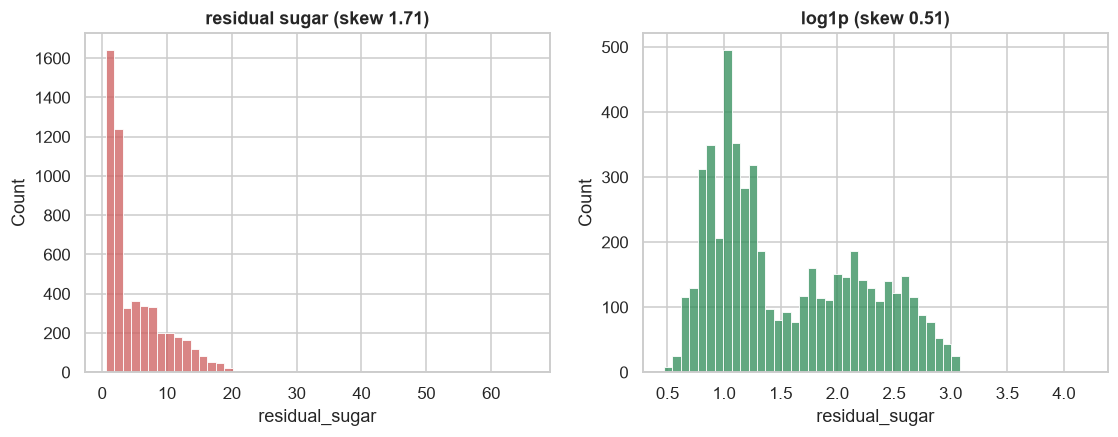

In [2]:
sk = pd.DataFrame({"raw skew": df[data.SKEWED].skew(),
                   "log1p skew": np.log1p(df[data.SKEWED]).skew()}).round(2).sort_values("raw skew", ascending=False)
print(sk.to_string())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.residual_sugar, bins=50, ax=ax[0], color="indianred"); ax[0].set_title(f"residual sugar (skew {df.residual_sugar.skew():.2f})")
sns.histplot(np.log1p(df.residual_sugar), bins=50, ax=ax[1], color="seagreen"); ax[1].set_title(f"log1p (skew {np.log1p(df.residual_sugar).skew():.2f})")
eda.savefig(fig, "p3_skew.png"); plt.show()

### 2. Outliers — real wines, not errors

The extremes are *plausible chemistry*, not data-entry mistakes: a 65 g/L residual-sugar wine is a
genuine dessert white. We **keep** them (they carry real signal) but note that linear models and the
raw-scale distance methods are sensitive to them — another reason trees are attractive here.

In [3]:
ext = df.nlargest(3, "residual_sugar")[["residual_sugar","alcohol","density","quality","wine_type"]]
print("sweetest wines (real dessert whites):"); print(ext.to_string())
print("\nmax chlorides %.2f, max free SO2 %.0f, max total SO2 %.0f — extreme but physically possible"
      % (df.chlorides.max(), df.free_sulfur_dioxide.max(), df.total_sulfur_dioxide.max()))

sweetest wines (real dessert whites):
      residual_sugar  alcohol  density  quality wine_type
3653           65.80     11.7  1.03898        6     white
2753           31.60      8.8  1.01030        6     white
4314           26.05     10.6  1.00295        6     white

max chlorides 0.61, max free SO2 289, max total SO2 440 — extreme but physically possible


### 3. Engineered chemistry — a ratio that beats them all

Domain knowledge suggests combinations: **bound SO₂** (total − free), the **free/total SO₂ ratio**,
**total acidity**, and **alcohol ÷ density** (a normalised "strength"). The last one correlates
**+0.48** with quality — *better than alcohol alone* (+0.45). A good engineered feature can out-predict
every raw measurement.

In [4]:
e = data.engineer(df)
rows = [(c, e[c].corr(e.quality, method="spearman")) for c in data.ENGINEERED + ["alcohol"]]
print(pd.DataFrame(rows, columns=["feature","spearman_vs_quality"]).set_index("feature").round(3).sort_values("spearman_vs_quality").to_string())
print("\n-> alcohol_density (+0.48) edges out raw alcohol (+0.45); so2_ratio adds a little too.")

                 spearman_vs_quality
feature                             
total_acidity                 -0.126
bound_so2                     -0.099
so2_ratio                      0.151
alcohol_density                0.480
alcohol                        0.480

-> alcohol_density (+0.48) edges out raw alcohol (+0.45); so2_ratio adds a little too.


### 4. Scaling, and does any of it help?

**Standardization** (mean 0, sd 1) matters for linear/distance models, not for trees. The honest
test: does log-transforming help a logistic-regression model predict "good wine" (quality ≥ 7)? Only
**marginally** — and a tree wouldn't benefit at all. The lesson: *match the preprocessing to the
model; don't transform on autopilot.*

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
y = (df.quality >= 7).astype(int)
Xr = df[data.NUMERIC]; Xl = Xr.copy()
for c in data.SKEWED: Xl[c] = np.log1p(Xl[c])
sc = lambda X: cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), X, y, cv=5, scoring="roc_auc").mean()
print("LogReg ROC-AUC (good-wine ≥7):  raw %.3f  ->  log-transformed %.3f  (marginal)" % (sc(Xr), sc(Xl)))
Xe = data.engineer(df)[data.NUMERIC + data.ENGINEERED]
print("                                +engineered features %.3f" % sc(Xe))

LogReg ROC-AUC (good-wine ≥7):  raw 0.823  ->  log-transformed 0.825  (marginal)
                                +engineered features 0.823


### Takeaways

- **Log transforms** rescue the skewed features for *linear* models (sugar 1.7 → 0.5) but can't fix a
  hard outlier (chlorides) and are *irrelevant to trees*.
- The **outliers are real** (a 65 g/L dessert wine) — keep them, but prefer models robust to scale.
- **Engineered chemistry pays off**: `alcohol/density` (+0.48) beats every raw feature — domain
  knowledge > raw columns.
- **Preprocessing is model-dependent**: transforms gave a logistic model only a sliver, and would give
  a tree nothing. Don't preprocess on autopilot.

**Next — Part 4 (Modeling framework):** the honest setup — dedup → stratified split, the
classification-vs-regression-vs-**ordinal** fork, the right metric for an imbalanced ordinal target
(**quadratic weighted kappa**), cross-validation, and baselines.